In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC,  OneClassSVM
from sklearn.model_selection import train_test_split,  GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.datasets import load_iris, load_digits, make_moons, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [61]:
#preprocessing
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["target"] = iris.target

df = df[df["target"] != 2]

train, valid, test = np.split(
    df.sample(frac=1, random_state=42),
    [int(0.6 * len(df)), int(0.8 * len(df))]
)

def scaling(dataframe, oversample=False):
    if isinstance(dataframe, pd.DataFrame):
        x = dataframe[dataframe.columns[:-1]].values
        y = dataframe[dataframe.columns[-1]].values
    else:
        x = dataframe[:, :-1]
        y = dataframe[:, -1]

    scaler = StandardScaler()
    X = scaler.fit_transform(x)

    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)

    data = np.hstack((X, np.reshape(y, (-1, 1))))
    return data, X, y.astype(int)

train_data, X_train, y_train = scaling(train, oversample=True)
valid_data, X_valid, y_valid = scaling(valid, oversample=False)
test_data,  X_test,  y_test  = scaling(test,  oversample=False)

In [62]:
#implementation
class SVM:
  
    def __init__(self, iterations=1000, lr=0.01, lambdaa=0.01):
        self.lambdaa = lambdaa
        self.iterations = iterations
        self.lr = lr
        self.w = None
        self.b = None

    def initialize_parameters(self, X):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0

    def fit(self, X, y):
        self.initialize_parameters(X)
        for i in range(self.iterations):
            self.gradient_descent(X, y)
            
    def gradient_descent(self, X, y):
        y_ = np.where(y <= 0, -1, 1)
        for i, x in enumerate(X):
            # Change subtraction (-) to addition (+) here
            if y_[i] * (np.dot(x, self.w) + self.b) >= 1:
                dw = 2 * self.lambdaa * self.w
                db = 0
            else:
                dw = 2 * self.lambdaa * self.w - (y_[i] * x)
                db = -y_[i] 
            self.update_parameters(dw, db)

    def update_parameters(self, dw, db):
        self.w = self.w - self.lr * dw
        self.b = self.b - self.lr * db

    def predict(self, X):
        output = np.dot(X, self.w) + self.b
        
        # Standard SVM prediction uses the raw sign directly:
        # If output >= 0 -> class 1, if output < 0 -> class 0
        return np.where(output >= 0, 1, 0)
    
def accuracy(y_true, y_pred):
    
    total_samples = len(y_true)
    correct_predictions = np.sum(y_true == y_pred)
    return (correct_predictions / total_samples) 

model = SVM()
model.fit(X_train,y_train)
predictions = model.predict(X_test)

accuracy(y_test, predictions)


np.float64(1.0)

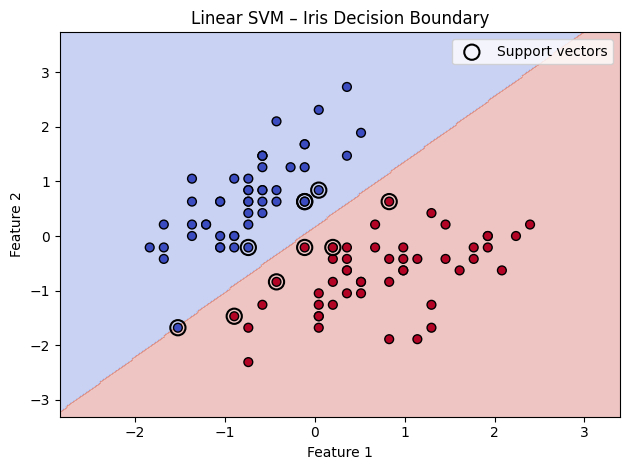

No. of support vectors: 10


In [63]:
#Linear SVM – Decision Boundary on Iris

iris = load_iris()
X = iris.data[:100, :2]   # 2 features, 2 classes
y = iris.target[:100]

sc = StandardScaler()
X = sc.fit_transform(X)

model = SVC(kernel='linear', C=1.0)
model.fit(X, y)

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k', s=40)
sv = model.support_vectors_
plt.scatter(sv[:,0], sv[:,1], s=120, facecolors='none',
            edgecolors='black', linewidths=1.5, label='Support vectors')
plt.legend(); plt.title('Linear SVM – Iris Decision Boundary')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.tight_layout(); plt.show()
print(f"No. of support vectors: {model.support_vectors_.shape[0]}")

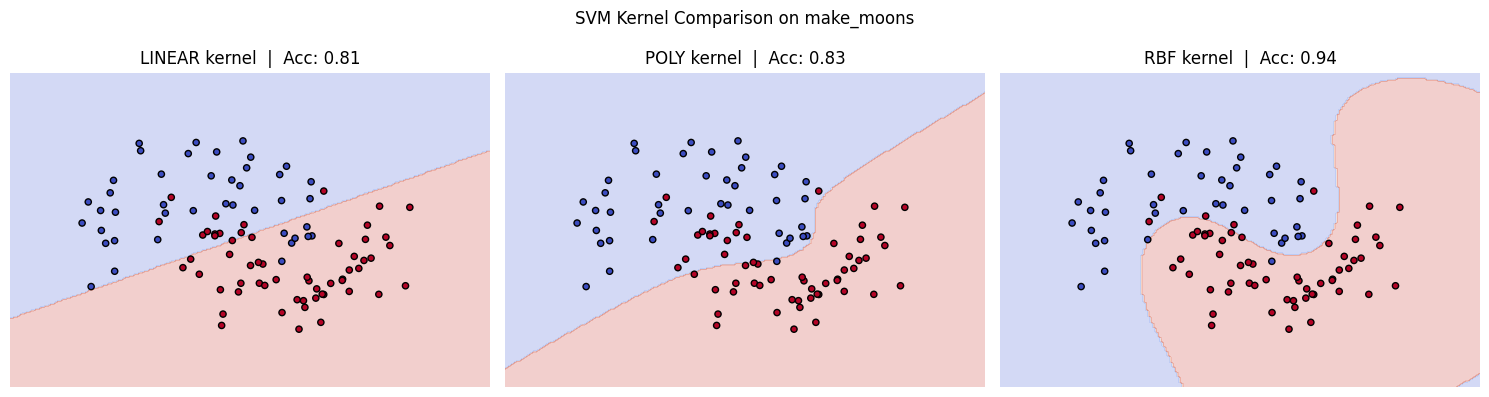

In [64]:
# Kernel Comparison – Linear vs Poly vs RBF

X, y = make_moons(n_samples=400, noise=0.25, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25)
sc = StandardScaler(); X_tr=sc.fit_transform(X_tr); X_te=sc.transform(X_te)

kernels = ['linear', 'poly', 'rbf']
colors  = ['#534AB7', '#0F6E56', '#185FA5']
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, k, col in zip(axes, kernels, colors):
    clf = SVC(kernel=k, degree=3).fit(X_tr, y_tr)
    acc = clf.score(X_te, y_te)
    xx,yy = np.meshgrid(np.linspace(-3,3,200), np.linspace(-3,3,200))
    Z = clf.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx,yy,Z,alpha=0.25,cmap='coolwarm')
    ax.scatter(X_te[:,0],X_te[:,1],c=y_te,cmap='coolwarm',edgecolors='k',s=20)
    ax.set_title(f"{k.upper()} kernel  |  Acc: {acc:.2f}")
    ax.axis('off')

plt.suptitle('SVM Kernel Comparison on make_moons')
plt.tight_layout(); plt.show()

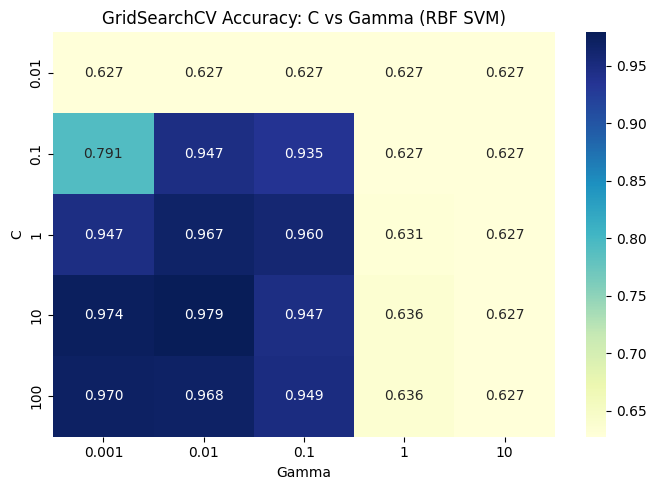

Best params : {'C': 10, 'gamma': 0.01}
Best CV acc : 0.9789


In [65]:
#Hyperparameter Tuning – GridSearchCV Heatmap

X, y = load_breast_cancer(return_X_y=True)
sc = StandardScaler(); X = sc.fit_transform(X)

param_grid = {
    'C':     [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10]
}
gs = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, n_jobs=-1)
gs.fit(X, y)

scores = gs.cv_results_['mean_test_score'].reshape(5,5)
plt.figure(figsize=(7,5))
sns.heatmap(scores, annot=True, fmt='.3f', cmap='YlGnBu',
            xticklabels=param_grid['gamma'],
            yticklabels=param_grid['C'])
plt.xlabel('Gamma'); plt.ylabel('C')
plt.title('GridSearchCV Accuracy: C vs Gamma (RBF SVM)')
plt.tight_layout(); plt.show()
print(f"Best params : {gs.best_params_}")
print(f"Best CV acc : {gs.best_score_:.4f}")

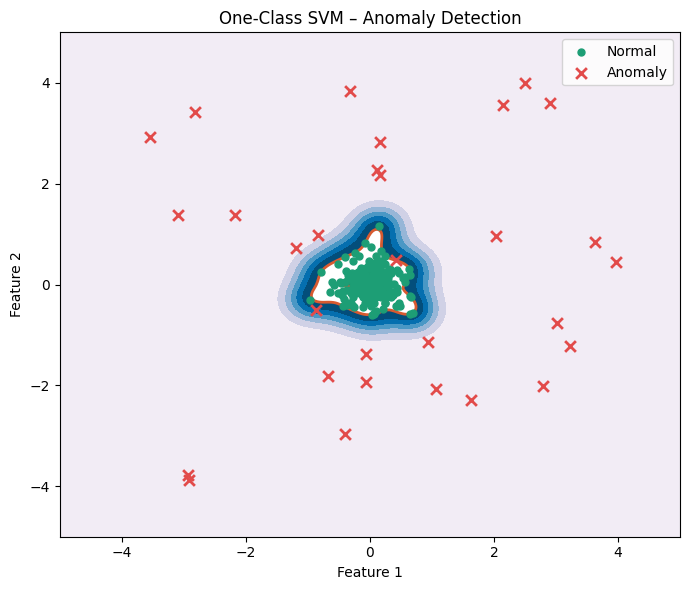

Anomalies detected: 30 / 30


In [66]:
#One-Class SVM – Anomaly Detection

np.random.seed(42)
# Normal data: tight cluster
X_normal  = 0.3 * np.random.randn(200, 2)
# Anomalies: scattered far away
X_anomaly = np.random.uniform(low=-4, high=4, size=(30, 2))

model = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
model.fit(X_normal)

xx,yy = np.meshgrid(np.linspace(-5,5,300), np.linspace(-5,5,300))
Z = model.decision_function(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(),0,7), cmap='PuBu')
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='#D85A30')
plt.scatter(X_normal[:,0],  X_normal[:,1],  c='#1D9E75', s=25, label='Normal',  zorder=3)
plt.scatter(X_anomaly[:,0], X_anomaly[:,1], c='#E24B4A', s=60, marker='x',
            linewidths=2, label='Anomaly', zorder=3)
plt.legend(); plt.title('One-Class SVM – Anomaly Detection')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.tight_layout(); plt.show()

preds = model.predict(X_anomaly)
detected = np.sum(preds == -1)
print(f"Anomalies detected: {detected} / {len(X_anomaly)}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       0.97      1.00      0.99        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.94      0.97        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



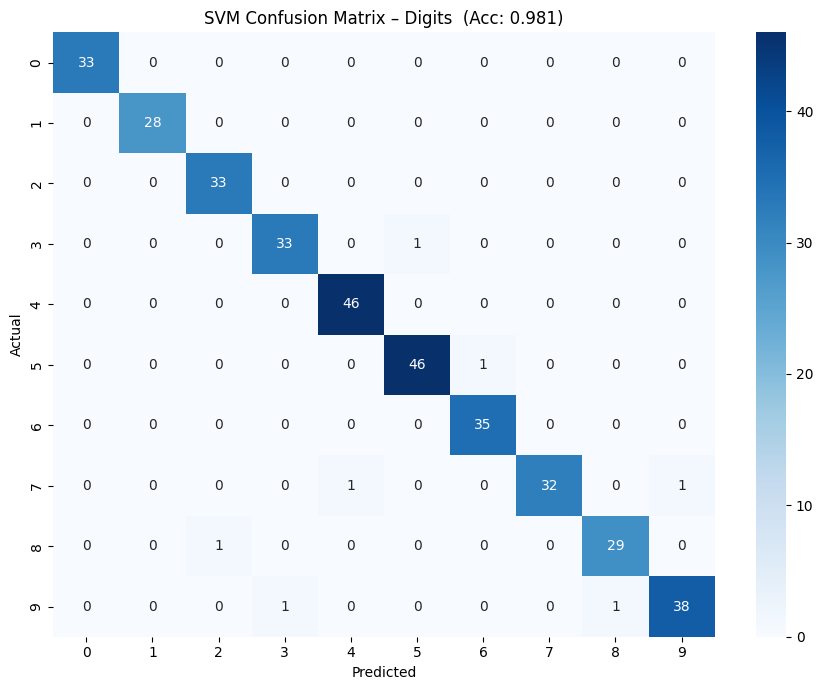

In [67]:
# Multi-class SVM – Digits Dataset
digits = load_digits()
X, y = digits.data, digits.target
X_tr,X_te,y_tr,y_te = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler(); X_tr=sc.fit_transform(X_tr); X_te=sc.transform(X_te)

model = SVC(kernel='rbf', C=10, gamma='scale')
model.fit(X_tr, y_tr); pred = model.predict(X_te)

print(classification_report(y_te, pred))
cm = confusion_matrix(y_te, pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'SVM Confusion Matrix – Digits  (Acc: {model.score(X_te,y_te):.3f})')
plt.tight_layout(); plt.show()
